In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "alaaramadann"
os.environ['KAGGLE_KEY'] = "KGAT_a48769f3d5cbf48183a820d5ccdfe790"

In [ ]:
!pip install kaggle

from google.colab import files
files.upload()
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle (2).json
mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
import os
import shutil

kaggle_path = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_path, exist_ok=True)

files = [f for f in os.listdir('.') if f.startswith('kaggle') and f.endswith('.json')]

if files:
    source_file = files[0]
    destination_file = os.path.join(kaggle_path, "kaggle.json")

    shutil.copy(source_file, destination_file)

    os.chmod(destination_file, 0o600)
    print(f"✅ تم بنجاح! نقلنا ملف {source_file} وبقى جاهز للشغل.")
else:
    print("❌ مالقتش أي ملف بيبدأ بـ kaggle.. اتأكدي إنك رفعتيه في الفولدر اللي على الشمال.")

✅ تم بنجاح! نقلنا ملف kaggle (1).json وبقى جاهز للشغل.


In [ ]:
!kaggle datasets download -d aryashah2k/nfuqnidsv2-network-intrusion-detection-dataset

!unzip -q nfuqnidsv2-network-intrusion-detection-dataset.zip -d nfuq_data

!rm nfuqnidsv2-network-intrusion-detection-dataset.zip

!ls -lh nfuq_data/

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/nfuqnidsv2-network-intrusion-detection-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:14<00:00, 148MB/s]

total 13G
-rw-r--r-- 1 root root 13G May 14  2022 NF-UQ-NIDS-v2.csv


In [ ]:
import pandas as pd

df_preview = pd.read_csv('nfuq_data/NF-UQ-NIDS-v2.csv', nrows=100000)

print("الأعمدة المتاحة في الداتا سيت (43 عمود):")
print(df_preview.columns.tolist())

print("\nتوزيع الهجمات في العينة:")
print(df_preview['Attack'].value_counts())

الأعمدة المتاحة في الداتا سيت (43 عمود):
['IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'Label', 'Attack', 'Dataset']

توزيع الهجمات في العينة:
Attack
Benign            32986
DDoS           

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

INPUT_FILE = 'nfuq_data/NF-UQ-NIDS-v2.csv'
OUTPUT_FILE = 'net_knight_final_balanced2.csv'
CHUNK_SIZE = 100_000
MIN_COUNT = 10_000

selected_features = [
    'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'OUT_BYTES',
    'IN_PKTS', 'OUT_PKTS', 'TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS',
    'TCP_WIN_MAX_IN', 'MIN_TTL', 'SHORTEST_FLOW_PKT'
]
target = 'Attack'

EXCLUDED_ATTACKS = ['Infilteration', 'mitm', 'Reconnaissance','Exploits', 'Fuzzers', 'Generic','Backdoor']



print("🚀 Pass 1: Counting and filtering classes...")
class_counts = {}

for chunk in pd.read_csv(INPUT_FILE, usecols=[target], chunksize=CHUNK_SIZE):

    for label, count in chunk[target].value_counts().items():
        class_counts[label] = class_counts.get(label, 0) + count

selected_labels = {k for k, v in class_counts.items()
                   if v >= MIN_COUNT and k not in EXCLUDED_ATTACKS}

print(f"\n✅ Selected labels for training: {selected_labels}")

sample_sizes = {label: 105_000 if label == 'Benign' else 100_000 for label in selected_labels}
sample_rates = {label: min(1.0, sample_sizes[label] / class_counts[label]) for label in selected_labels}

print(f"\n🚀 Pass 2: Engineering features and writing to {OUTPUT_FILE}...")

if os.path.exists(OUTPUT_FILE):
    os.remove(OUTPUT_FILE)

written = 0
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, usecols=selected_features + [target], chunksize=CHUNK_SIZE)):
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
    chunk.dropna(inplace=True)

    if chunk.empty: continue


    chunk['Packet_Density'] = chunk['IN_BYTES'] / (chunk['IN_PKTS'] + 1)
    chunk['Flow_Symmetry'] = chunk['OUT_BYTES'] / (chunk['IN_BYTES'] + 1)
    chunk['Symmetry_Ratio'] = chunk['IN_PKTS'] / (chunk['OUT_PKTS'] + 0.001)
    chunk['Byte_Symmetry'] = chunk['IN_BYTES'] / (chunk['IN_BYTES'] + chunk['OUT_BYTES'] + 1)

    duration_sec = chunk['FLOW_DURATION_MILLISECONDS'] / 1000.0
    chunk['Packet_Rate'] = (chunk['IN_PKTS'] + chunk['OUT_PKTS']) / (duration_sec + 0.001)
    chunk['Byte_Rate'] = (chunk['IN_BYTES'] + chunk['OUT_BYTES']) / (duration_sec + 0.001)
    chunk['Aggressiveness'] = chunk['IN_BYTES'] / (chunk['FLOW_DURATION_MILLISECONDS'] + 0.001)

    chunk['Pkt_Size_Avg'] = (chunk['IN_BYTES'] + chunk['OUT_BYTES']) / (chunk['IN_PKTS'] + chunk['OUT_PKTS'] + 1)
    chunk['Is_SYN_Only'] = ((chunk['PROTOCOL'] == 6) & (chunk['TCP_FLAGS'] == 2)).astype(int)

    common_ports = [80, 443, 53, 21, 22, 23, 25, 3389]
    chunk['Is_Common_Port'] = chunk['L4_DST_PORT'].isin(common_ports).astype(int)

    parts = []
    for label in selected_labels:
        sub = chunk[chunk[target] == label]
        if len(sub) == 0: continue
        n = max(1, int(len(sub) * sample_rates[label]))
        parts.append(sub.sample(n=min(n, len(sub)), random_state=42))

    if not parts: continue

    sampled = pd.concat(parts, ignore_index=True)
    sampled.to_csv(OUTPUT_FILE, mode='a', header=(written == 0), index=False)
    written += len(sampled)

    if i % 50 == 0:
        print(f" 🟢 Chunk {i} processed | Rows written: {written:,}")

print(f"\n✨ Done! Total Balanced Rows: {written:,}")

🚀 Pass 1: Counting and filtering classes...

✅ Selected labels for training: {'injection', 'xss', 'Bot', 'Benign', 'Brute Force', 'password', 'DDoS', 'scanning', 'DoS'}

🚀 Pass 2: Engineering features and writing to net_knight_final_balanced2.csv...
 🟢 Chunk 0 processed | Rows written: 1,218
 🟢 Chunk 50 processed | Rows written: 60,659
 🟢 Chunk 100 processed | Rows written: 120,015
 🟢 Chunk 150 processed | Rows written: 179,383
 🟢 Chunk 200 processed | Rows written: 238,843
 🟢 Chunk 250 processed | Rows written: 297,875
 🟢 Chunk 300 processed | Rows written: 357,334
 🟢 Chunk 350 processed | Rows written: 416,847
 🟢 Chunk 400 processed | Rows written: 476,120
 🟢 Chunk 450 processed | Rows written: 535,394
 🟢 Chunk 500 processed | Rows written: 594,627
 🟢 Chunk 550 processed | Rows written: 653,907
 🟢 Chunk 600 processed | Rows written: 713,272
 🟢 Chunk 650 processed | Rows written: 772,606
 🟢 Chunk 700 processed | Rows written: 831,719
 🟢 Chunk 750 processed | Rows written: 891,089

✨ D

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('net_knight_final_balanced2.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901549 entries, 0 to 901548
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   L4_DST_PORT                 901549 non-null  int64  
 1   PROTOCOL                    901549 non-null  int64  
 2   L7_PROTO                    901549 non-null  float64
 3   IN_BYTES                    901549 non-null  int64  
 4   IN_PKTS                     901549 non-null  int64  
 5   OUT_BYTES                   901549 non-null  int64  
 6   OUT_PKTS                    901549 non-null  int64  
 7   TCP_FLAGS                   901549 non-null  int64  
 8   FLOW_DURATION_MILLISECONDS  901549 non-null  int64  
 9   MIN_TTL                     901549 non-null  int64  
 10  SHORTEST_FLOW_PKT           901549 non-null  int64  
 11  TCP_WIN_MAX_IN              901549 non-null  int64  
 12  Attack                      901549 non-null  object 
 13  Packet_Density

In [ ]:
df.head()

,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,FLOW_DURATION_MILLISECONDS,MIN_TTL,...,Packet_Density,Flow_Symmetry,Symmetry_Ratio,Byte_Symmetry,Packet_Rate,Byte_Rate,Aggressiveness,Pkt_Size_Avg,Is_SYN_Only,Is_Common_Port
0,80,6,7.0,561,5,696,4,27,0,64,...,93.500000,1.238434,1.249688,0.445946,9000.000000,1.257000e+06,561000.000000,125.700000,0,1
1,80,6,7.0,164,3,112,2,19,4294936,64,...,41.000000,0.678788,1.499250,0.592058,0.001164,6.426171e-02,0.000038,46.000000,0,1
2,80,6,7.0,496,5,3812,7,27,0,64,...,82.666667,7.670020,0.714184,0.115108,12000.000000,4.308000e+06,496000.000000,331.384615,0,1
3,80,6,7.0,549,4,687,3,30,0,64,...,109.800000,1.249091,1.332889,0.443816,7000.000000,1.236000e+06,549000.000000,154.500000,0,1
4,80,6,7.0,620,6,12815,12,27,0,64,...,88.571429,20.636071,0.499958,0.046145,18000.000000,1.343500e+07,620000.000000,707.105263,0,1


In [ ]:
df['Attack'].value_counts()

,count
Attack,
Benign,104630
Brute Force,99627
password,99626
DDoS,99620
DoS,99616
scanning,99614
injection,99611
xss,99610
Bot,99595


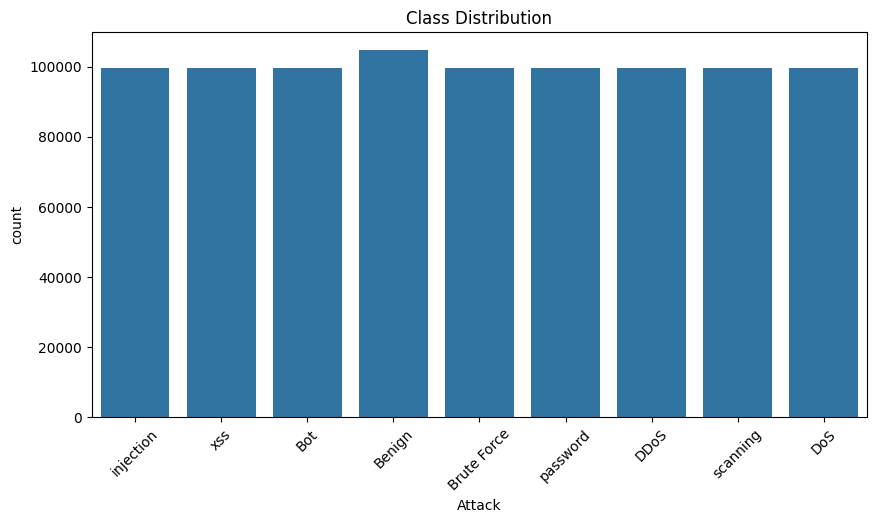

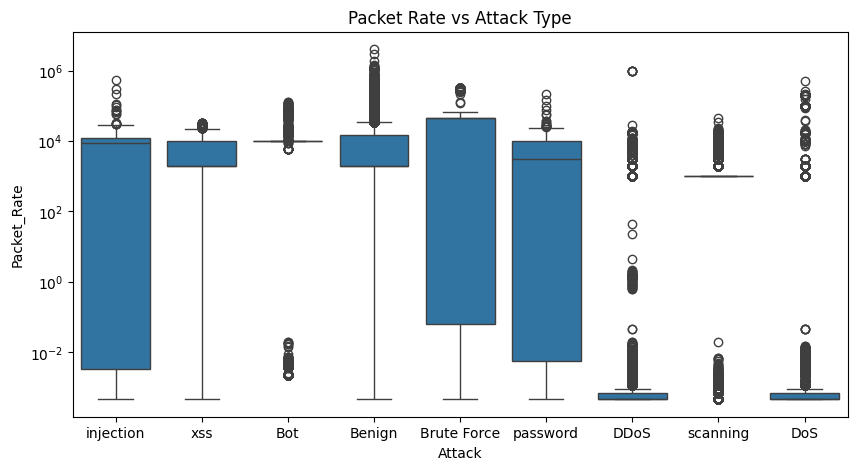

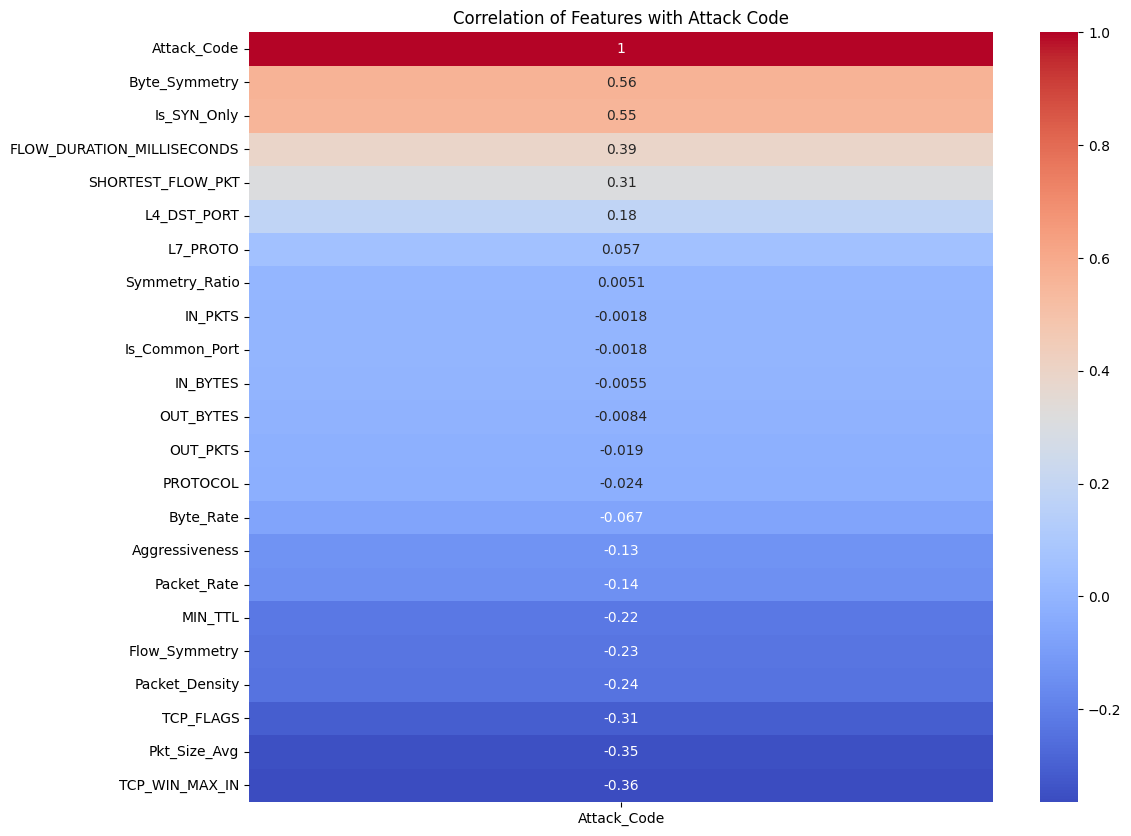

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(x='Attack', data=df)
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='Attack', y='Packet_Rate', data=df)
plt.yscale('log')
plt.title('Packet Rate vs Attack Type')
plt.show()

plt.figure(figsize=(12, 10))

df_numeric = df.copy()
df_numeric['Attack_Code'] = pd.factorize(df['Attack'])[0]

numeric_only = df_numeric.select_dtypes(include=[np.number])
correlation_matrix = numeric_only.corr()

sns.heatmap(correlation_matrix[['Attack_Code']].sort_values(by='Attack_Code', ascending=False),
            annot=True, cmap='coolwarm')

plt.title('Correlation of Features with Attack Code')
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('net_knight_final_balanced2.csv')

key_features = [
    'Is_SYN_Only', 'Byte_Symmetry', 'Packet_Rate',
    'TCP_FLAGS', 'IN_PKTS', 'OUT_PKTS', 'L4_DST_PORT'
]

def get_attack_patterns(data, label_column='Attack'):
    patterns = []

    attack_types = data[label_column].unique()

    for attack in attack_types:
        subset = data[data[label_column] == attack]

        pattern = subset[key_features].mean().to_dict()
        pattern['Attack_Type'] = attack
        pattern['Sample_Count'] = len(subset)

        pattern['Common_TCP_Flag'] = subset['TCP_FLAGS'].mode()[0]

        patterns.append(pattern)

    return pd.DataFrame(patterns)

signatures = get_attack_patterns(df)

signatures = signatures[['Attack_Type', 'Is_SYN_Only', 'Common_TCP_Flag', 'Packet_Rate', 'Byte_Symmetry', 'IN_PKTS']]
print("🚀 Attack Patterns (The Signature Bible):")
print(signatures.to_string(index=False))

signatures.to_csv('attack_patterns_reference.csv', index=False)

🚀 Attack Patterns (The Signature Bible):
Attack_Type  Is_SYN_Only  Common_TCP_Flag  Packet_Rate  Byte_Symmetry   IN_PKTS
  injection     0.000020               27  7477.980226       0.349695  5.359950
        xss     0.000311                0  5531.954924       0.527930  3.890935
        Bot     0.000000              219  9491.129355       0.608781  5.288498
     Benign     0.161885                0 12965.690527       0.504330  9.555386
Brute Force     0.000000               27 29590.783266       0.480628 36.622693
   password     0.020426               27  5441.704054       0.323121  7.542429
       DDoS     0.003011                0   258.785761       0.898185  9.731670
   scanning     0.593832                2  1323.870171       0.851756  1.104283
        DoS     0.822659                2  1054.650577       0.944955  3.325048


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import gc


X = df.drop(columns=['Attack'])
y = df['Attack']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

del X, df
gc.collect()

cat_cols = ['PROTOCOL', 'L7_PROTO', 'TCP_FLAGS', 'Is_Common_Port', 'Is_SYN_Only', 'L4_DST_PORT']
cols_to_log = [
    'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS',
    'FLOW_DURATION_MILLISECONDS', 'TCP_WIN_MAX_IN',
    'SHORTEST_FLOW_PKT',
    'Packet_Rate', 'Byte_Rate', 'Packet_Density',
    'Aggressiveness', 'Pkt_Size_Avg'
]
ratio_cols = ['Flow_Symmetry', 'Symmetry_Ratio', 'Byte_Symmetry', 'MIN_TTL']

print("Applying Log1p transformation...")
for col in cols_to_log:
    X_train[col] = np.log1p(X_train[col].astype(float))
    X_test[col] = np.log1p(X_test[col].astype(float))

print("Standardizing numerical features...")
num_cols = cols_to_log + ratio_cols
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

models = {
    "LightGBM": LGBMClassifier(
        n_estimators=500, learning_rate=0.015, max_depth=7, num_leaves=31,
        min_child_samples=100, feature_fraction=0.7, lambda_l1=2.0, lambda_l2=2.0,
       random_state=42, verbose=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500, learning_rate=0.015, max_depth=7,
        reg_alpha=2.0, reg_lambda=2.0, subsample=0.7,
        tree_method='hist', device="cuda",
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=50,
         random_state=42, n_jobs=-1
    )
}

results = []
best_f1 = 0
best_model_obj = None

print("🏆 The Competition Begins (Behavioral Mode)...")

for name, model in models.items():
    print(f"⏳ Training {name}...")
    if name == "XGBoost":
        model.fit(X_train.apply(pd.to_numeric), y_train)
        y_pred = model.predict(X_test.apply(pd.to_numeric))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)

    print(f"✅ {name} Finished | F1-Score: {f1:.4f} | Acc: {acc:.4f}")

    results.append({"Model": name, "F1-Score": f1, "Accuracy": acc})

    if f1 > best_f1:
        best_f1 = f1
        best_model_obj = model
        best_name = name
if "XGBoost" in models:
    xgb_model_obj = models["XGBoost"]
    joblib.dump(xgb_model_obj, 'net_knight_XGBoost_v5.pkl')
    print("🚀 XGBoost model has been saved separately as 'net_knight_XGBoost_v5.pkl'")
comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("\n📊 Leaderboard:")
print(comparison_df)

print(f"\n🥇 Best Model is {best_name}5. Saving...")
joblib.dump(best_model_obj, f'best_net_knight_{best_name}5.pkl')
joblib.dump(scaler, 'net_knight_scaler_final5.pkl')
joblib.dump(le, 'attack_label_encoder5.pkl')

Applying Log1p transformation...
Standardizing numerical features...
🏆 The Competition Begins (Behavioral Mode)...
⏳ Training LightGBM...
✅ LightGBM Finished | F1-Score: 0.9681 | Acc: 0.9682
⏳ Training XGBoost...
✅ XGBoost Finished | F1-Score: 0.9650 | Acc: 0.9652
⏳ Training RandomForest...
✅ RandomForest Finished | F1-Score: 0.9614 | Acc: 0.9614
🚀 XGBoost model has been saved separately as 'net_knight_XGBoost_v5.pkl'

📊 Leaderboard:
          Model  F1-Score  Accuracy
0      LightGBM  0.968073  0.968210
1       XGBoost  0.964997  0.965154
2  RandomForest  0.961389  0.961450

🥇 Best Model is LightGBM5. Saving...


['attack_label_encoder5.pkl']


📊 Evaluating Model: LightGBM
✅ Accuracy: 0.9682
⚖️ Balanced Acc: 0.9681
------------------------------
📄 Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99     20926
         Bot       1.00      1.00      1.00     19919
 Brute Force       1.00      0.98      0.99     19926
        DDoS       0.97      0.99      0.98     19924
         DoS       1.00      0.99      0.99     19923
   injection       0.92      0.88      0.90     19922
    password       0.94      0.95      0.94     19925
    scanning       0.99      0.99      0.99     19923
         xss       0.90      0.95      0.93     19922

    accuracy                           0.97    180310
   macro avg       0.97      0.97      0.97    180310
weighted avg       0.97      0.97      0.97    180310



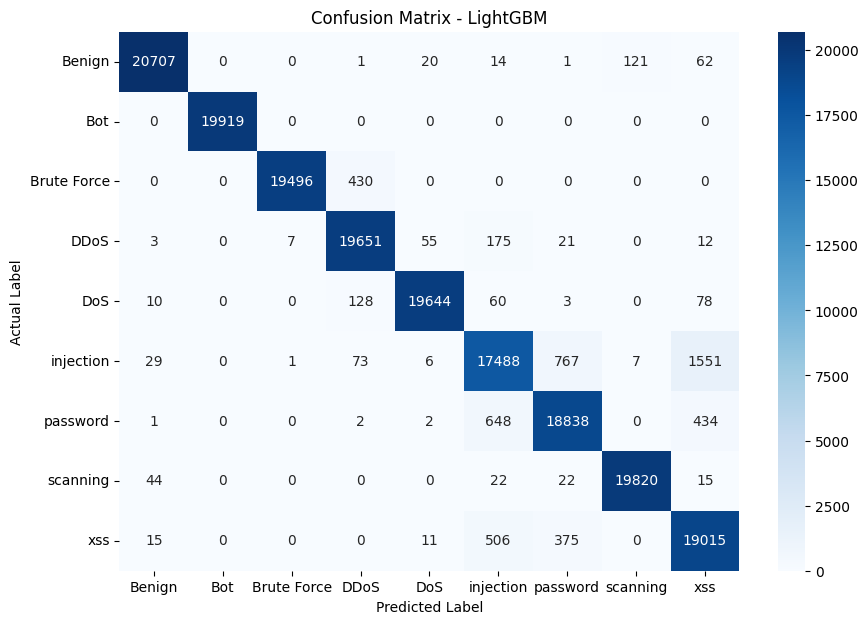

<Figure size 1000x600 with 0 Axes>

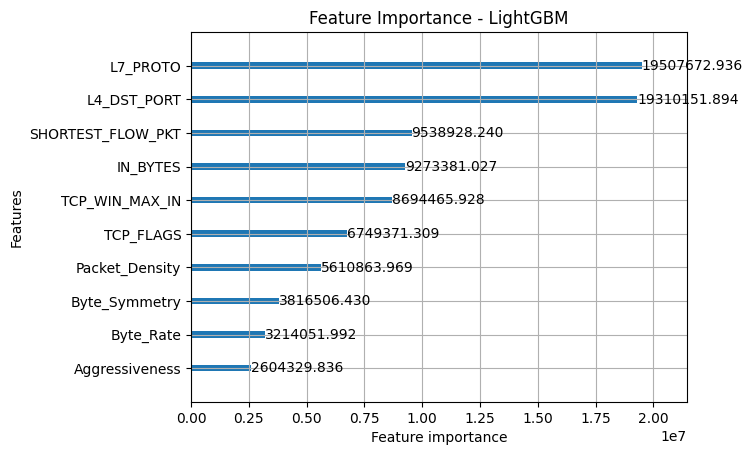


************************************************************


📊 Evaluating Model: XGBoost
✅ Accuracy: 0.9652
⚖️ Balanced Acc: 0.9650
------------------------------
📄 Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99     20926
         Bot       1.00      1.00      1.00     19919
 Brute Force       1.00      0.98      0.99     19926
        DDoS       0.97      0.98      0.98     19924
         DoS       0.99      0.99      0.99     19923
   injection       0.91      0.87      0.89     19922
    password       0.93      0.94      0.93     19925
    scanning       0.99      0.99      0.99     19923
         xss       0.89      0.95      0.92     19922

    accuracy                           0.97    180310
   macro avg       0.97      0.97      0.96    180310
weighted avg       0.97      0.97      0.97    180310



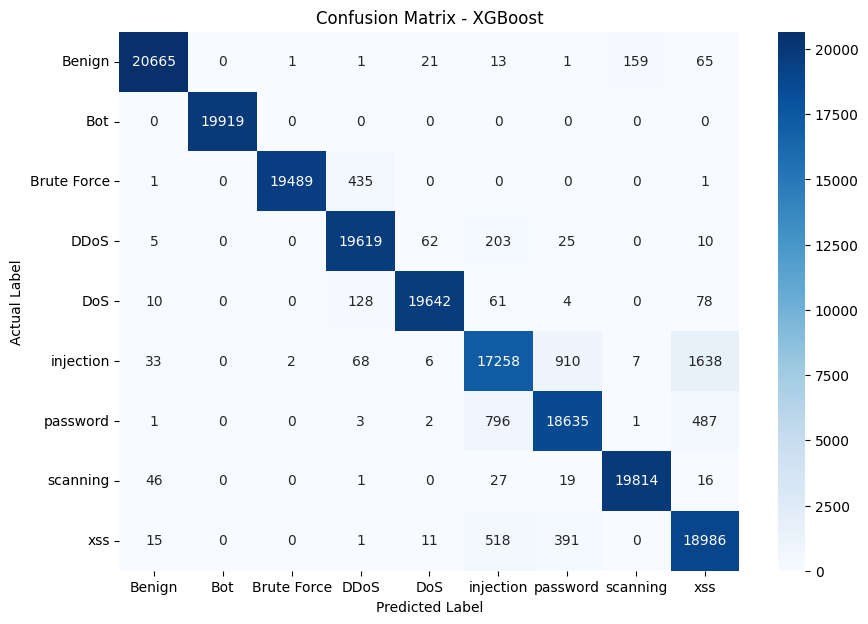

<Figure size 1000x600 with 0 Axes>

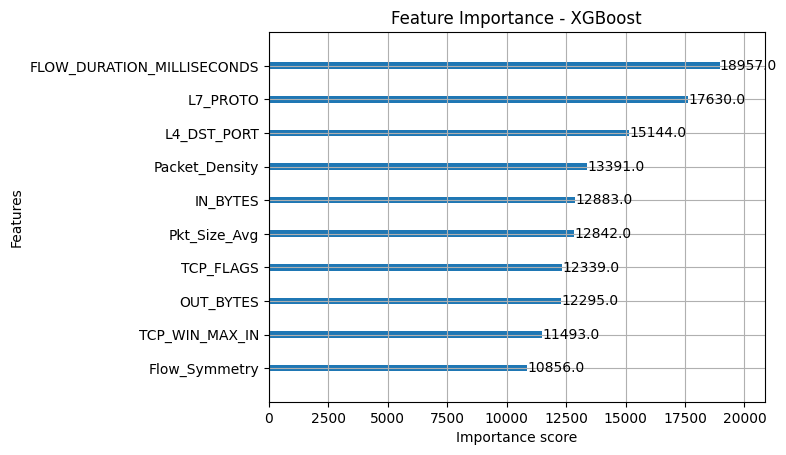


************************************************************


📊 Evaluating Model: RandomForest
✅ Accuracy: 0.9614
⚖️ Balanced Acc: 0.9613
------------------------------
📄 Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99     20926
         Bot       1.00      1.00      1.00     19919
 Brute Force       1.00      0.98      0.99     19926
        DDoS       0.97      0.98      0.97     19924
         DoS       0.99      0.98      0.99     19923
   injection       0.89      0.87      0.88     19922
    password       0.94      0.91      0.93     19925
    scanning       0.99      0.99      0.99     19923
         xss       0.89      0.95      0.92     19922

    accuracy                           0.96    180310
   macro avg       0.96      0.96      0.96    180310
weighted avg       0.96      0.96      0.96    180310



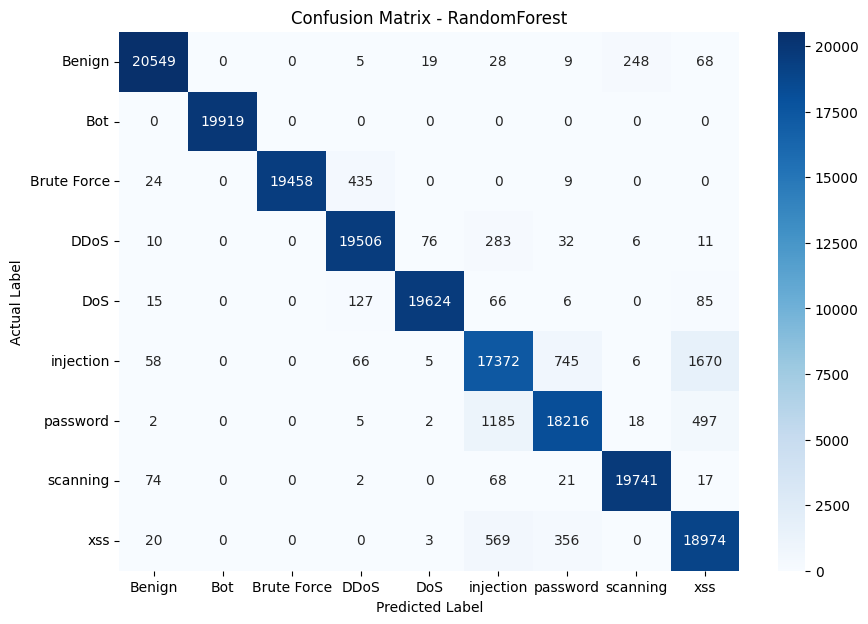

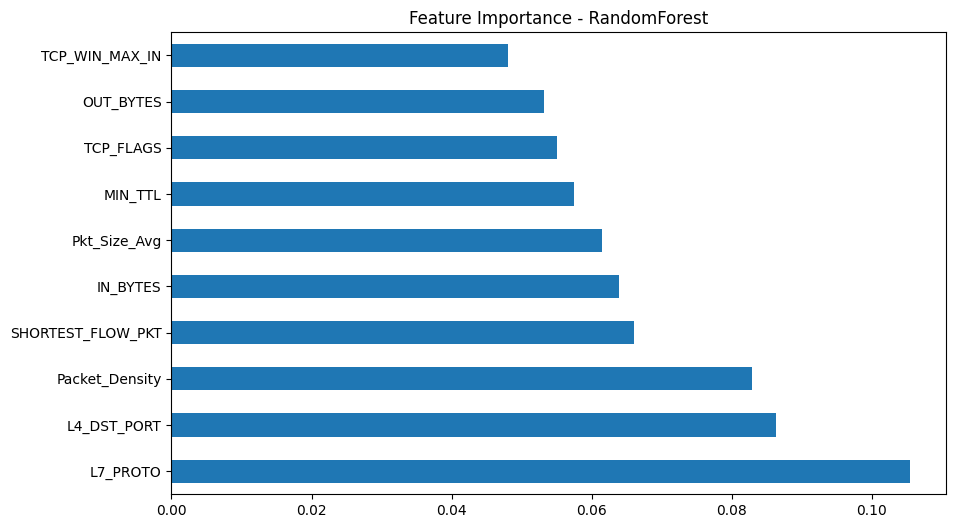


************************************************************



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score
import xgboost as xgb
import lightgbm as lgb

for name, model in models.items():
    print("\n" + "="*60)
    print(f"📊 Evaluating Model: {name}")
    print("="*60)

    if name == "XGBoost":
        test_data = X_test.apply(pd.to_numeric)
    else:
        test_data = X_test

    y_pred = model.predict(test_data)

    print(f"✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"⚖️ Balanced Acc: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print("-" * 30)
    print("📄 Detailed Classification Report:")
    target_names = le.inverse_transform(np.unique(y_test))
    print(classification_report(y_test, y_pred, target_names=target_names))

    plt.figure(figsize=(10, 7))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    plt.figure(figsize=(10, 6))
    try:
        if name == "LightGBM":
            lgb.plot_importance(model, max_num_features=10, importance_type='gain', title=f'Feature Importance - {name}')
        elif name == "XGBoost":
            xgb.plot_importance(model, max_num_features=10, importance_type='weight', title=f'Feature Importance - {name}')
        else:
            feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
            feat_importances.nlargest(10).plot(kind='barh')
            plt.title(f'Feature Importance - {name}')
    except Exception as e:
        print(f"⚠️ Could not plot importance for {name}: {e}")

    plt.show()
    print("\n" + "*"*60 + "\n")

In [ ]:
joblib.dump(X_train.columns.tolist(), 'feature_names3.pkl')

['feature_names3.pkl']

In [ ]:
import pandas as pd
import numpy as np
import joblib

model = joblib.load('net_knight_XGBoost_v5.pkl')
scaler = joblib.load('net_knight_scaler_final5.pkl')
le = joblib.load('attack_label_encoder5.pkl')
feature_names = joblib.load('feature_names3.pkl')

sample_flow = {
    'L4_DST_PORT': 80,
    'PROTOCOL': 6,
    'L7_PROTO': 7.0,
    'IN_BYTES': 5000,
    'OUT_BYTES': 0,
    'IN_PKTS': 100,
    'OUT_PKTS': 0,
    'TCP_FLAGS': 2,
    'FLOW_DURATION_MILLISECONDS': 1500,
    'TCP_WIN_MAX_IN': 512,
    'MIN_TTL': 64,
    'SHORTEST_FLOW_PKT': 40
}

def predict_single_flow(data):
    df_test = pd.DataFrame([data])

    df_test['Packet_Density'] = df_test['IN_BYTES'] / (df_test['IN_PKTS'] + 1)
    df_test['Flow_Symmetry'] = df_test['OUT_BYTES'] / (df_test['IN_BYTES'] + 1)
    df_test['Symmetry_Ratio'] = df_test['IN_PKTS'] / (df_test['OUT_PKTS'] + 0.001)
    df_test['Byte_Symmetry'] = df_test['IN_BYTES'] / (df_test['IN_BYTES'] + df_test['OUT_BYTES'] + 1)

    duration_sec = df_test['FLOW_DURATION_MILLISECONDS'] / 1000.0
    df_test['Packet_Rate'] = (df_test['IN_PKTS'] + df_test['OUT_PKTS']) / (duration_sec + 0.001)
    df_test['Byte_Rate'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (duration_sec + 0.001)
    df_test['Aggressiveness'] = df_test['IN_BYTES'] / (df_test['FLOW_DURATION_MILLISECONDS'] + 0.001)
    df_test['Pkt_Size_Avg'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (df_test['IN_PKTS'] + df_test['OUT_PKTS'] + 1)
    df_test['Is_SYN_Only'] = ((df_test['PROTOCOL'] == 6) & (df_test['TCP_FLAGS'] == 2)).astype(int)

    common_ports = [80, 443, 53, 21, 22, 23, 25, 3389]
    df_test['Is_Common_Port'] = df_test['L4_DST_PORT'].isin(common_ports).astype(int)

    cat_cols = ['PROTOCOL', 'L7_PROTO', 'TCP_FLAGS', 'Is_Common_Port', 'Is_SYN_Only', 'L4_DST_PORT']
    cols_to_log = ['IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS',
                   'TCP_WIN_MAX_IN', 'SHORTEST_FLOW_PKT',
                   'Packet_Rate', 'Byte_Rate', 'Packet_Density', 'Aggressiveness', 'Pkt_Size_Avg']
    ratio_cols = ['Flow_Symmetry', 'Symmetry_Ratio', 'Byte_Symmetry', 'MIN_TTL']
    num_cols = cols_to_log + ratio_cols

    df_test = df_test[feature_names]

    for col in cols_to_log:
        df_test[col] = np.log1p(df_test[col].astype(float))

    df_test[num_cols] = scaler.transform(df_test[num_cols])

    for col in cat_cols:
      df_test[col] = df_test[col].astype(int).astype('category')
    prob = model.predict_proba(df_test)[0]
    idx = np.argmax(prob)
    label = le.inverse_transform([idx])[0]

    return label, prob[idx]

result_label, confidence = predict_single_flow(sample_flow)

print("--- 🛡️ Net-Knight Test Result ---")
print(f"Prediction: {result_label}")
print(f"Confidence: {confidence * 100:.2f}%")

--- 🛡️ Net-Knight Test Result ---
Prediction: DoS
Confidence: 49.78%


In [ ]:
import pandas as pd
import numpy as np
import joblib

model = joblib.load('best_net_knight_LightGBM5.pkl')
scaler = joblib.load('net_knight_scaler_final5.pkl')
le = joblib.load('attack_label_encoder5.pkl')
feature_names = joblib.load('feature_names3.pkl')

sample_flow = {
    'L4_DST_PORT': 22,
    'PROTOCOL': 6,
    'L7_PROTO': 0.0,
    'IN_BYTES': 1240,
    'OUT_BYTES': 980,
    'IN_PKTS': 15,
    'OUT_PKTS': 12,
    'TCP_FLAGS': 24,
    'FLOW_DURATION_MILLISECONDS': 200,
    'TCP_WIN_MAX_IN': 1024,
    'MIN_TTL': 64,
    'SHORTEST_FLOW_PKT': 50
}

def predict_single_flow(data):
    df_test = pd.DataFrame([data])

    df_test['Packet_Density'] = df_test['IN_BYTES'] / (df_test['IN_PKTS'] + 1)
    df_test['Flow_Symmetry'] = df_test['OUT_BYTES'] / (df_test['IN_BYTES'] + 1)
    df_test['Symmetry_Ratio'] = df_test['IN_PKTS'] / (df_test['OUT_PKTS'] + 0.001)
    df_test['Byte_Symmetry'] = df_test['IN_BYTES'] / (df_test['IN_BYTES'] + df_test['OUT_BYTES'] + 1)

    duration_sec = df_test['FLOW_DURATION_MILLISECONDS'] / 1000.0
    df_test['Packet_Rate'] = (df_test['IN_PKTS'] + df_test['OUT_PKTS']) / (duration_sec + 0.001)
    df_test['Byte_Rate'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (duration_sec + 0.001)
    df_test['Aggressiveness'] = df_test['IN_BYTES'] / (df_test['FLOW_DURATION_MILLISECONDS'] + 0.001)
    df_test['Pkt_Size_Avg'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (df_test['IN_PKTS'] + df_test['OUT_PKTS'] + 1)
    df_test['Is_SYN_Only'] = ((df_test['PROTOCOL'] == 6) & (df_test['TCP_FLAGS'] == 2)).astype(int)

    common_ports = [80, 443, 53, 21, 22, 23, 25, 3389]
    df_test['Is_Common_Port'] = df_test['L4_DST_PORT'].isin(common_ports).astype(int)

    cat_cols = ['PROTOCOL', 'L7_PROTO', 'TCP_FLAGS', 'Is_Common_Port', 'Is_SYN_Only', 'L4_DST_PORT']
    cols_to_log = ['IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS',
                   'TCP_WIN_MAX_IN', 'SHORTEST_FLOW_PKT',
                   'Packet_Rate', 'Byte_Rate', 'Packet_Density', 'Aggressiveness', 'Pkt_Size_Avg']
    ratio_cols = ['Flow_Symmetry', 'Symmetry_Ratio', 'Byte_Symmetry', 'MIN_TTL']
    num_cols = cols_to_log + ratio_cols

    df_test = df_test[feature_names]

    for col in cols_to_log:
        df_test[col] = np.log1p(df_test[col].astype(float))

    df_test[num_cols] = scaler.transform(df_test[num_cols])

    for col in cat_cols:
      df_test[col] = df_test[col].astype(int).astype('category')
    prob = model.predict_proba(df_test)[0]
    idx = np.argmax(prob)
    label = le.inverse_transform([idx])[0]

    return label, prob[idx]

result_label, confidence = predict_single_flow(sample_flow)

print("--- 🛡️ Net-Knight Test Result ---")
print(f"Prediction: {result_label}")
print(f"Confidence: {confidence * 100:.2f}%")

--- 🛡️ Net-Knight Test Result ---
Prediction: Benign
Confidence: 63.06%


In [ ]:
import pandas as pd
import numpy as np
import joblib

model = joblib.load('net_knight_XGBoost_v5.pkl')
scaler = joblib.load('net_knight_scaler_final5.pkl')
le = joblib.load('attack_label_encoder5.pkl')
feature_names = joblib.load('feature_names3.pkl')

sample_flow = {
    'L4_DST_PORT': 80,
    'PROTOCOL': 6,
    'L7_PROTO': 7.0,
    'IN_BYTES': 1200,
    'OUT_BYTES': 0,
    'IN_PKTS': 20,
    'OUT_PKTS': 0,
    'TCP_FLAGS': 2,
    'FLOW_DURATION_MILLISECONDS': 15000,
    'TCP_WIN_MAX_IN': 512,
    'MIN_TTL': 64,
    'SHORTEST_FLOW_PKT': 60
}
def predict_single_flow(data):
    df_test = pd.DataFrame([data])

    df_test['Packet_Density'] = df_test['IN_BYTES'] / (df_test['IN_PKTS'] + 1)
    df_test['Flow_Symmetry'] = df_test['OUT_BYTES'] / (df_test['IN_BYTES'] + 1)
    df_test['Symmetry_Ratio'] = df_test['IN_PKTS'] / (df_test['OUT_PKTS'] + 0.001)
    df_test['Byte_Symmetry'] = df_test['IN_BYTES'] / (df_test['IN_BYTES'] + df_test['OUT_BYTES'] + 1)

    duration_sec = df_test['FLOW_DURATION_MILLISECONDS'] / 1000.0
    df_test['Packet_Rate'] = (df_test['IN_PKTS'] + df_test['OUT_PKTS']) / (duration_sec + 0.001)
    df_test['Byte_Rate'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (duration_sec + 0.001)
    df_test['Aggressiveness'] = df_test['IN_BYTES'] / (df_test['FLOW_DURATION_MILLISECONDS'] + 0.001)
    df_test['Pkt_Size_Avg'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (df_test['IN_PKTS'] + df_test['OUT_PKTS'] + 1)
    df_test['Is_SYN_Only'] = ((df_test['PROTOCOL'] == 6) & (df_test['TCP_FLAGS'] == 2)).astype(int)

    common_ports = [80, 443, 53, 21, 22, 23, 25, 3389]
    df_test['Is_Common_Port'] = df_test['L4_DST_PORT'].isin(common_ports).astype(int)

    cat_cols = ['PROTOCOL', 'L7_PROTO', 'TCP_FLAGS', 'Is_Common_Port', 'Is_SYN_Only', 'L4_DST_PORT']
    cols_to_log = ['IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS',
                   'TCP_WIN_MAX_IN', 'SHORTEST_FLOW_PKT',
                   'Packet_Rate', 'Byte_Rate', 'Packet_Density', 'Aggressiveness', 'Pkt_Size_Avg']
    ratio_cols = ['Flow_Symmetry', 'Symmetry_Ratio', 'Byte_Symmetry', 'MIN_TTL']
    num_cols = cols_to_log + ratio_cols

    df_test = df_test[feature_names]

    for col in cols_to_log:
        df_test[col] = np.log1p(df_test[col].astype(float))

    df_test[num_cols] = scaler.transform(df_test[num_cols])

    for col in cat_cols:
      df_test[col] = df_test[col].astype(int).astype('category')

    probs = model.predict_proba(df_test)[0]

    top_indices = np.argsort(probs)[::-1][:3]

    print("\n--- 🕵️ Deep Diagnostic Result ---")
    for i in top_indices:
        label = le.inverse_transform([i])[0]
        confidence = probs[i] * 100
        print(f"Rank {np.where(top_indices==i)[0][0]+1}: {label} ({confidence:.2f}%)")

    return le.inverse_transform([top_indices[0]])[0], probs[top_indices[0]]

result_label, confidence = predict_single_flow(sample_flow)

print("--- 🛡️ Net-Knight Test Result ---")
print(f"Prediction: {result_label}")
print(f"Confidence: {confidence * 100:.2f}%")


--- 🕵️ Deep Diagnostic Result ---
Rank 1: Benign (50.72%)
Rank 2: DoS (43.47%)
Rank 3: Brute Force (1.73%)
--- 🛡️ Net-Knight Test Result ---
Prediction: Benign
Confidence: 50.72%


IndentationError: unexpected indent (1058138192.py, line 2)

In [ ]:
import pandas as pd
import numpy as np
import joblib

model = joblib.load('best_net_knight_LightGBM4.pkl')
scaler = joblib.load('net_knight_scaler_final4.pkl')
le = joblib.load('attack_label_encoder4.pkl')
feature_names = joblib.load('feature_names2.pkl')

sample_flow = {
    'L4_DST_PORT': 8080,
    'PROTOCOL': 6,
    'L7_PROTO': 0.0,
    'IN_BYTES': 480,
    'OUT_BYTES': 240,
    'IN_PKTS': 8,
    'OUT_PKTS': 4,
    'TCP_FLAGS': 24,
    'FLOW_DURATION_MILLISECONDS': 120000,
    'TCP_WIN_MAX_IN': 256,
    'MIN_TTL': 128,
    'SHORTEST_FLOW_PKT': 60
}
def predict_single_flow(data):
    df_test = pd.DataFrame([data])

    df_test['Packet_Density'] = df_test['IN_BYTES'] / (df_test['IN_PKTS'] + 1)
    df_test['Flow_Symmetry'] = df_test['OUT_BYTES'] / (df_test['IN_BYTES'] + 1)
    df_test['Symmetry_Ratio'] = df_test['IN_PKTS'] / (df_test['OUT_PKTS'] + 0.001)
    df_test['Byte_Symmetry'] = df_test['IN_BYTES'] / (df_test['IN_BYTES'] + df_test['OUT_BYTES'] + 1)

    duration_sec = df_test['FLOW_DURATION_MILLISECONDS'] / 1000.0
    df_test['Packet_Rate'] = (df_test['IN_PKTS'] + df_test['OUT_PKTS']) / (duration_sec + 0.001)
    df_test['Byte_Rate'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (duration_sec + 0.001)
    df_test['Aggressiveness'] = df_test['IN_BYTES'] / (df_test['FLOW_DURATION_MILLISECONDS'] + 0.001)
    df_test['Pkt_Size_Avg'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (df_test['IN_PKTS'] + df_test['OUT_PKTS'] + 1)
    df_test['Is_SYN_Only'] = ((df_test['PROTOCOL'] == 6) & (df_test['TCP_FLAGS'] == 2)).astype(int)

    common_ports = [80, 443, 53, 21, 22, 23, 25, 3389]
    df_test['Is_Common_Port'] = df_test['L4_DST_PORT'].isin(common_ports).astype(int)

    cat_cols = ['PROTOCOL', 'L7_PROTO', 'TCP_FLAGS', 'Is_Common_Port', 'Is_SYN_Only', 'L4_DST_PORT']
    cols_to_log = ['IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS',
                   'TCP_WIN_MAX_IN', 'SHORTEST_FLOW_PKT',
                   'Packet_Rate', 'Byte_Rate', 'Packet_Density', 'Aggressiveness', 'Pkt_Size_Avg']
    ratio_cols = ['Flow_Symmetry', 'Symmetry_Ratio', 'Byte_Symmetry', 'MIN_TTL']
    num_cols = cols_to_log + ratio_cols

    df_test = df_test[feature_names]

    for col in cols_to_log:
        df_test[col] = np.log1p(df_test[col].astype(float))

    df_test[num_cols] = scaler.transform(df_test[num_cols])

    for col in cat_cols:
      df_test[col] = df_test[col].astype(int).astype('category')
    prob = model.predict_proba(df_test)[0]
    idx = np.argmax(prob)
    label = le.inverse_transform([idx])[0]

    return label, prob[idx]

result_label, confidence = predict_single_flow(sample_flow)

print("--- 🛡️ Net-Knight Test Result ---")
print(f"Prediction: {result_label}")
print(f"Confidence: {confidence * 100:.2f}%")

--- 🛡️ Net-Knight Test Result ---
Prediction: Benign
Confidence: 94.19%


In [ ]:
import pandas as pd
import numpy as np
import joblib

model = joblib.load('net_knight_XGBoost_v5.pkl')
scaler = joblib.load('net_knight_scaler_final5.pkl')
le = joblib.load('attack_label_encoder5.pkl')
feature_names = joblib.load('feature_names3.pkl')

sample_flow = {
    'L4_DST_PORT': 443,
    'PROTOCOL': 6,
    'L7_PROTO': 91.0,
    'IN_BYTES': 1500,
    'OUT_BYTES': 4500,
    'IN_PKTS': 20,
    'OUT_PKTS': 35,
    'TCP_FLAGS': 26,
    'FLOW_DURATION_MILLISECONDS': 800,
    'TCP_WIN_MAX_IN': 65535,
    'MIN_TTL': 64,
    'SHORTEST_FLOW_PKT': 54
}

def predict_single_flow(data):
    df_test = pd.DataFrame([data])

    df_test['Packet_Density'] = df_test['IN_BYTES'] / (df_test['IN_PKTS'] + 1)
    df_test['Flow_Symmetry'] = df_test['OUT_BYTES'] / (df_test['IN_BYTES'] + 1)
    df_test['Symmetry_Ratio'] = df_test['IN_PKTS'] / (df_test['OUT_PKTS'] + 0.001)
    df_test['Byte_Symmetry'] = df_test['IN_BYTES'] / (df_test['IN_BYTES'] + df_test['OUT_BYTES'] + 1)

    duration_sec = df_test['FLOW_DURATION_MILLISECONDS'] / 1000.0
    df_test['Packet_Rate'] = (df_test['IN_PKTS'] + df_test['OUT_PKTS']) / (duration_sec + 0.001)
    df_test['Byte_Rate'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (duration_sec + 0.001)
    df_test['Aggressiveness'] = df_test['IN_BYTES'] / (df_test['FLOW_DURATION_MILLISECONDS'] + 0.001)
    df_test['Pkt_Size_Avg'] = (df_test['IN_BYTES'] + df_test['OUT_BYTES']) / (df_test['IN_PKTS'] + df_test['OUT_PKTS'] + 1)
    df_test['Is_SYN_Only'] = ((df_test['PROTOCOL'] == 6) & (df_test['TCP_FLAGS'] == 2)).astype(int)

    common_ports = [80, 443, 53, 21, 22, 23, 25, 3389]
    df_test['Is_Common_Port'] = df_test['L4_DST_PORT'].isin(common_ports).astype(int)

    cat_cols = ['PROTOCOL', 'L7_PROTO', 'TCP_FLAGS', 'Is_Common_Port', 'Is_SYN_Only', 'L4_DST_PORT']
    cols_to_log = ['IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS',
                   'TCP_WIN_MAX_IN', 'SHORTEST_FLOW_PKT',
                   'Packet_Rate', 'Byte_Rate', 'Packet_Density', 'Aggressiveness', 'Pkt_Size_Avg']
    ratio_cols = ['Flow_Symmetry', 'Symmetry_Ratio', 'Byte_Symmetry', 'MIN_TTL']
    num_cols = cols_to_log + ratio_cols

    df_test = df_test[feature_names]

    for col in cols_to_log:
        df_test[col] = np.log1p(df_test[col].astype(float))

    df_test[num_cols] = scaler.transform(df_test[num_cols])

    for col in cat_cols:
      df_test[col] = df_test[col].astype(int).astype('category')
    prob = model.predict_proba(df_test)[0]
    idx = np.argmax(prob)
    label = le.inverse_transform([idx])[0]

    return label, prob[idx]

result_label, confidence = predict_single_flow(sample_flow)

print("--- 🛡️ Net-Knight Test Result ---")
print(f"Prediction: {result_label}")
print(f"Confidence: {confidence * 100:.2f}%")

--- 🛡️ Net-Knight Test Result ---
Prediction: Benign
Confidence: 58.96%


In [ ]:
import numpy as np

real_dos_idx = np.where(le.inverse_transform(y_test) == 'Backdoor')[0][0]
sample_row = X_test.iloc[[real_dos_idx]].apply(pd.to_numeric)

real_pred = model.predict(sample_row)[0]
real_prob = np.max(model.predict_proba(sample_row))

print(f"🎯 Real Data Test (DoS Row from Dataset):")
print(f"--- Predicted: {le.inverse_transform([real_pred])[0]} | Confidence: {real_prob*100:.2f}%")

ValueError: train and valid dataset categorical_feature do not match.

In [ ]:
import joblib

try:
    saved_features = joblib.load('feature_names.pkl')

    print("✅ الترتيب المخزن في السيستم عندك هو:")
    print("-" * 40)
    for i, feature in enumerate(saved_features):
        print(f"{i}: {feature}")
    print("-" * 40)

    manual_order = [
        'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS',
        'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS',
        'MIN_TTL', 'SHORTEST_FLOW_PKT', 'RETRANSMITTED_IN_BYTES', 'TCP_WIN_MAX_IN',
        'Packet_Density', 'Flow_Symmetry', 'Symmetry_Ratio', 'Byte_Symmetry',
        'Packet_Rate', 'Byte_Rate', 'Aggressiveness', 'Pkt_Size_Avg',
        'Is_SYN_Only', 'Is_Common_Port'
    ]

    if saved_features == manual_order:
        print("\n🔥 مبروك يا هندسة! الترتيب متطابق 100% وكله تمام.")
    else:
        print("\n⚠️ خد بالك! فيه اختلاف في الترتيب.. التزمي باللي طلع من الـ pkl.")

except FileNotFoundError:
    print("❌ ملف feature_names.pkl مش موجود.. اتأكدي إنك رنيتي سطر الـ dump الأول.")

✅ الترتيب المخزن في السيستم عندك هو:
----------------------------------------
0: L4_DST_PORT
1: PROTOCOL
2: L7_PROTO
3: IN_BYTES
4: IN_PKTS
5: OUT_BYTES
6: OUT_PKTS
7: TCP_FLAGS
8: FLOW_DURATION_MILLISECONDS
9: MIN_TTL
10: SHORTEST_FLOW_PKT
11: RETRANSMITTED_IN_BYTES
12: TCP_WIN_MAX_IN
13: Packet_Density
14: Flow_Symmetry
15: Symmetry_Ratio
16: Byte_Symmetry
17: Packet_Rate
18: Byte_Rate
19: Aggressiveness
20: Pkt_Size_Avg
21: Is_SYN_Only
22: Is_Common_Port
----------------------------------------

🔥 مبروك يا هندسة! الترتيب متطابق 100% وكله تمام.


In [ ]:
import joblib
import numpy as np

le = joblib.load('attack_label_encoder.pkl')
scaler = joblib.load('net_knight_scaler_final.pkl')
feature_names = joblib.load('feature_names.pkl')

print("🔍 --- فحص الـ Label Encoder (ترتيب الهجمات) ---")
for i, label in enumerate(le.classes_):
    print(f"Index {i} -> Attack Name: {label}")

print("\n📏 --- فحص الـ Scaler (سلامة المقاييس) ---")
print(f"✅ عدد الميزات داخل السكيلر: {scaler.n_features_in_}")
print(f"✅ عدد الميزات في قائمة feature_names: {len(feature_names)}")

if hasattr(scaler, 'feature_names_in_'):
    print("✅ السكيلر متطابق مع الأسماء الأصلية.")
else:
    print("⚠️ السكيلر متخزن كأرقام فقط (ده طبيعي)، المهم العدد يكون {0}".format(len(feature_names)))

print("\n🧐 --- فحص الـ Mean (المتوسطات) لأهم الميزات ---")
for i, col in enumerate(feature_names[:5]):
    print(f"Feature: {col} | Mean Value: {scaler.mean_[i]:.4f}")

if len(feature_names) == scaler.n_features_in_:
    print("\n🔥 النتيجة النهائية: الترتيب والسكيلر 'سمن على عسل' ومظبوطين 100%!")
else:
    print("\n❌ خطر! فيه اختلاف بين عدد الميزات في القائمة وبين السكيلر.")

🔍 --- فحص الـ Label Encoder (ترتيب الهجمات) ---
Index 0 -> Attack Name: Backdoor
Index 1 -> Attack Name: Benign
Index 2 -> Attack Name: Bot
Index 3 -> Attack Name: Brute Force
Index 4 -> Attack Name: Content-based
Index 5 -> Attack Name: DDoS
Index 6 -> Attack Name: DoS
Index 7 -> Attack Name: injection
Index 8 -> Attack Name: password
Index 9 -> Attack Name: scanning
Index 10 -> Attack Name: xss

📏 --- فحص الـ Scaler (سلامة المقاييس) ---
✅ عدد الميزات داخل السكيلر: 17
✅ عدد الميزات في قائمة feature_names: 23
✅ السكيلر متطابق مع الأسماء الأصلية.

🧐 --- فحص الـ Mean (المتوسطات) لأهم الميزات ---
Feature: L4_DST_PORT | Mean Value: 5.8123
Feature: PROTOCOL | Mean Value: 4.6235
Feature: L7_PROTO | Mean Value: 1.7133
Feature: IN_BYTES | Mean Value: 1.3781
Feature: IN_PKTS | Mean Value: 5.1172

❌ خطر! فيه اختلاف بين عدد الميزات في القائمة وبين السكيلر.
